In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Parametres communs
T = 1.0
N = 500
h = T / N
t = np.linspace(0, T, N + 1)

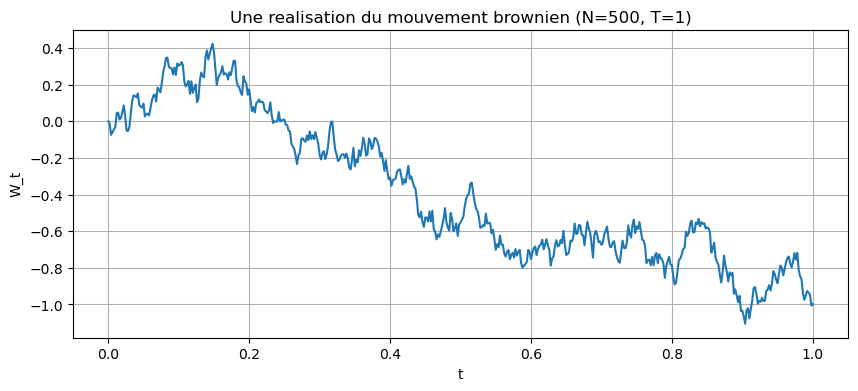

In [5]:
# W_0 = 0, increments dW_k ~ N(0, h), W_t = somme cumulee des increments

increments = np.random.normal(0, np.sqrt(h), N)
W = np.concatenate([[0], np.cumsum(increments)])

plt.figure(figsize=(10, 4))
plt.plot(t, W)
plt.xlabel('t')
plt.ylabel('W_t')
plt.title('Une realisation du mouvement brownien (N=500, T=1)')
plt.grid(True)
plt.show()

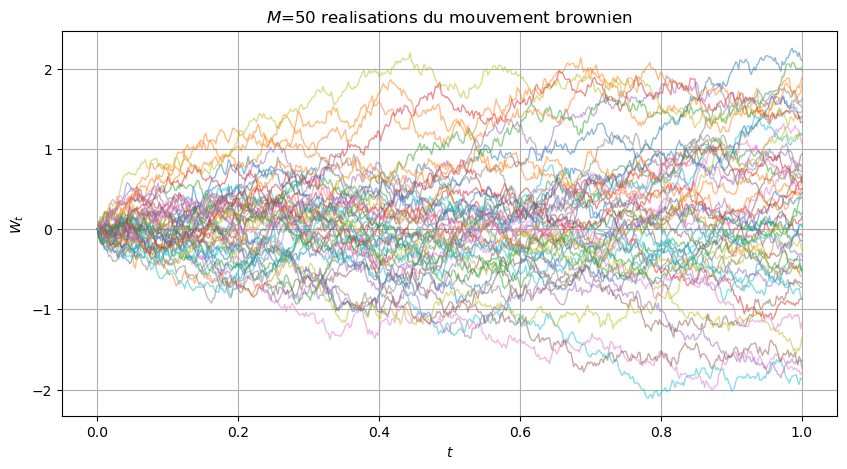

In [6]:
# Astuce : on genere une matrice (M, N) d'increments d'un coup

M = 50

increments_M = np.random.normal(0, np.sqrt(h), (M, N))
W_M = np.concatenate([np.zeros((M, 1)), np.cumsum(increments_M, axis=1)], axis=1)
# W_M a la forme (M, N+1) : chaque ligne est une realisation

plt.figure(figsize=(10, 5))
for i in range(M):
    plt.plot(t, W_M[i], alpha=0.5, linewidth=1)
plt.xlabel(r'$t$')
plt.ylabel(r'$W_t$')
plt.title(rf'$M$={M} realisations du mouvement brownien')
plt.grid(True)
plt.show()

In [7]:
# Formule de Riemann-Ito (4.3) : somme de W_{t_k} * (W_{t_{k+1}} - W_{t_k})
# Formule exacte (exercice 4.1 / Ito) : int_0^T W_t dW_t = (W_T^2 - T) / 2

# On fait varier h et on compare la moyenne empirique de l'integrale numerique avec la valeur exacte moyenne (qui vaut 0 en esperance)

M_mc = 2000  # nombre de realisations Monte Carlo
N_values = [10, 50, 100, 500, 1000]

erreurs = []

for N_h in N_values:
    h_val = T / N_h

    # Genere M_mc trajectoires de taille N_h
    inc = np.random.normal(0, np.sqrt(h_val), (M_mc, N_h))
    W_traj = np.concatenate([np.zeros((M_mc, 1)), np.cumsum(inc, axis=1)], axis=1)

    # Integrale de Riemann-Ito : sum_k W_{t_k} * (W_{t_{k+1}} - W_{t_k})
    integrale_numerique = np.sum(W_traj[:, :-1] * inc, axis=1)

    # Valeur exacte pour chaque trajectoire
    W_T = W_traj[:, -1]
    integrale_exacte = (W_T**2 - T) / 2

    # Erreur moyenne entre numerique et exacte
    erreur_moy = np.sqrt(np.mean(np.abs(integrale_numerique - integrale_exacte)**2))
    erreurs.append(erreur_moy)

    print(rf"$N$ = {N_h:5d}, $h$={h_val:.4f} | "
          f"Moy numerique={np.mean(integrale_numerique):.4f}, "
          f"Moy exacte={np.mean(integrale_exacte):.4f}, "
          f"Erreur moy={erreur_moy:.4f}")

$N$ =    10, $h$=0.1000 | Moy numerique=0.0142, Moy exacte=0.0142, Erreur moy=0.2261
$N$ =    50, $h$=0.0200 | Moy numerique=-0.0008, Moy exacte=0.0017, Erreur moy=0.1005
$N$ =   100, $h$=0.0100 | Moy numerique=0.0000, Moy exacte=-0.0001, Erreur moy=0.0706
$N$ =   500, $h$=0.0020 | Moy numerique=-0.0167, Moy exacte=-0.0164, Erreur moy=0.0310
$N$ =  1000, $h$=0.0010 | Moy numerique=0.0326, Moy exacte=0.0322, Erreur moy=0.0223


[0.22611568 0.10112201 0.07150406 0.03197759 0.02261157]


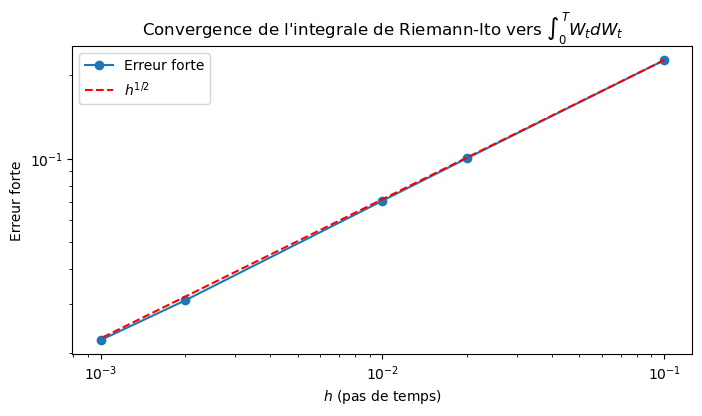

In [8]:
# Visualisation de l'erreur en fonction de h
h_values = [T / N_h for N_h in N_values]

C = erreurs[0] / h_values[0] ** 0.5
erreur_theo = C * np.array(h_values)**(.5)
print(erreur_theo)

plt.figure(figsize=(8, 4))
plt.loglog(h_values, erreurs, 'o-', label='Erreur forte')
plt.loglog(h_values, erreur_theo, label = r'$h^{1/2}$', linestyle = '--', color = 'red')
plt.xlabel(r'$h$ (pas de temps)')
plt.ylabel('Erreur forte')
plt.title(r"Convergence de l'integrale de Riemann-Ito vers $\int_0^T W_t dW_t$")
plt.legend()
#plt.grid(True)
plt.show()

$N$ =    10, $h$=0.1000 | Moy numerique=-0.0207, Moy exacte=-0.0266, Erreur moy=0.3426
$N$ =    50, $h$=0.0200 | Moy numerique=-0.0423, Moy exacte=-0.0454, Erreur moy=0.1441
$N$ =   100, $h$=0.0100 | Moy numerique=0.0102, Moy exacte=0.0132, Erreur moy=0.1016
$N$ =   500, $h$=0.0020 | Moy numerique=0.0043, Moy exacte=0.0038, Erreur moy=0.0426
$N$ =  1000, $h$=0.0010 | Moy numerique=-0.0025, Moy exacte=-0.0025, Erreur moy=0.0321
[0.34260508 0.15321765 0.10834124 0.04845167 0.03426051]


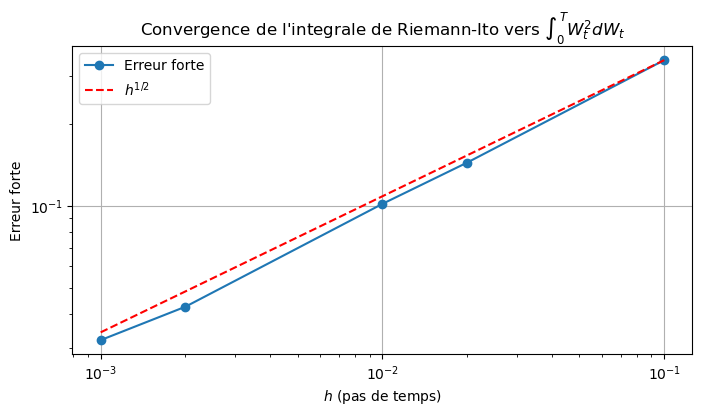

In [10]:
# Simulation de int_0^T W_t^2 dW_t : formule de Riemann-Ito : sum_k W_{t_k}^2 * (W_{t_{k+1}} - W_{t_k})
# Formule exacte : int_0^T W_t^2 dW_s = W_T**3/3 - int_0^T W_s ds 

T = 1.0
M_mc = 2000 # nombre de realisations Monte Carlo
N_values = [10, 50, 100, 500, 1000]

erreurs = []
for N_h in N_values:
    h_val = T / N_h

    # Genere M_mc trajectoires de taille N_h
    inc = np.random.normal(0, np.sqrt(h_val), (M_mc, N_h))
    W_traj = np.concatenate([np.zeros((M_mc, 1)), np.cumsum(inc, axis=1)], axis=1)

    # Integrale de Riemann-Ito : sum_k W_{t_k}^2 * (W_{t_{k+1}} - W_{t_k})
    integrale_numerique = np.sum(W_traj[:, :-1]**2 * inc, axis=1)

    # Valeur exacte pour chaque trajectoire
    W_T = W_traj[:, -1]
    integrale_exacte = W_T**3 / 3 - h_val * np.sum(W_traj[:, :-1], axis=1)
    
    # Erreur moyenne entre numerique et exacte
    erreur_moy = np.sqrt(np.mean(np.abs(integrale_numerique - integrale_exacte)**2))
    erreurs.append(erreur_moy)

    print(rf"$N$ = {N_h:5d}, $h$={h_val:.4f} | "
          f"Moy numerique={np.mean(integrale_numerique):.4f}, "
          f"Moy exacte={np.mean(integrale_exacte):.4f}, "
          f"Erreur moy={erreur_moy:.4f}")
    
# Visualisation de l'erreur en fonction de h
h_values = [T / N_h for N_h in N_values]
C = erreurs[0] / h_values[0] ** 0.5
erreur_theo = C * np.array(h_values)**(.5)
print(erreur_theo)
plt.figure(figsize=(8, 4))
plt.loglog(h_values, erreurs, 'o-', label='Erreur forte')
plt.loglog(h_values, erreur_theo, label = r'$h^{1/2}$', linestyle = '--', color = 'red')
plt.xlabel(r'$h$ (pas de temps)')
plt.ylabel('Erreur forte')
plt.title(r"Convergence de l'integrale de Riemann-Ito vers $\int_0^T W_t^2 dW_t$")
plt.legend()
plt.grid(True)
plt.show()